# 確率的シミュレーションの基礎：反復とばらつき

対応章: [`../chapters/06_agent_boarding_behavior.md`](../chapters/06_agent_boarding_behavior.md)

研究対象の行動ルールはまだ比較しない。単純なボトルネック模型でseedと反復実験を練習する。

## 1. ライブラリと基準設定

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

N_ALIGHT = 24
N_BOARD = 20
PASS_PROBABILITY = 0.72

## 2. 練習用ボトルネック模型

各時刻に確率 `pass_probability` で1人が通過する。降車完了後に乗車を開始する。

In [2]:
def simulate_baseline(seed, n_alight=N_ALIGHT, n_board=N_BOARD, pass_probability=PASS_PROBABILITY):
    rng = np.random.default_rng(seed)
    remaining_alight = n_alight
    remaining_board = n_board
    time = 0
    history = [(time, remaining_alight, remaining_board)]
    while remaining_alight + remaining_board > 0:
        time += 1
        if rng.random() < pass_probability:
            if remaining_alight > 0:
                remaining_alight -= 1
            elif remaining_board > 0:
                remaining_board -= 1
        history.append((time, remaining_alight, remaining_board))
    return time, np.asarray(history)

time_0, history_0 = simulate_baseline(seed=0)
time_repeat, _ = simulate_baseline(seed=0)
print('completion time:', time_0)
print('same seed reproduces result:', time_0 == time_repeat)

completion time: 62
same seed reproduces result: True


## 3. 1回の実行経過を見る

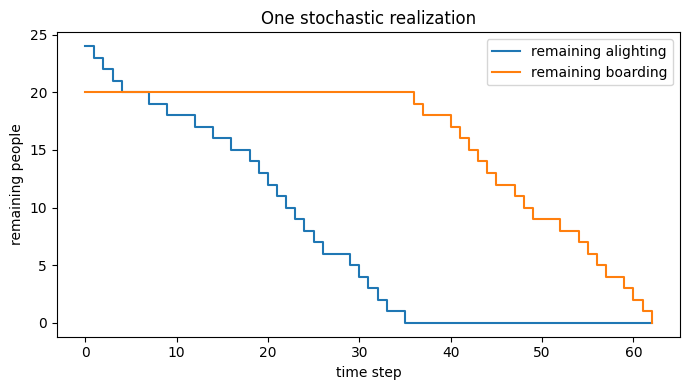

In [3]:
plt.figure(figsize=(7, 4))
plt.step(history_0[:, 0], history_0[:, 1], where='post', label='remaining alighting')
plt.step(history_0[:, 0], history_0[:, 2], where='post', label='remaining boarding')
plt.xlabel('time step'); plt.ylabel('remaining people')
plt.title('One stochastic realization')
plt.legend(); plt.tight_layout(); plt.show()

## 4. seedを変えて分布を作る

In [4]:
n_repeats = 200
times = np.array([simulate_baseline(seed)[0] for seed in range(n_repeats)])
summary = pd.Series(times).describe(percentiles=[0.25, 0.5, 0.75])
summary

count    200.000000
mean      61.575000
std        4.729292
min       50.000000
25%       58.000000
50%       62.000000
75%       65.000000
max       76.000000
dtype: float64

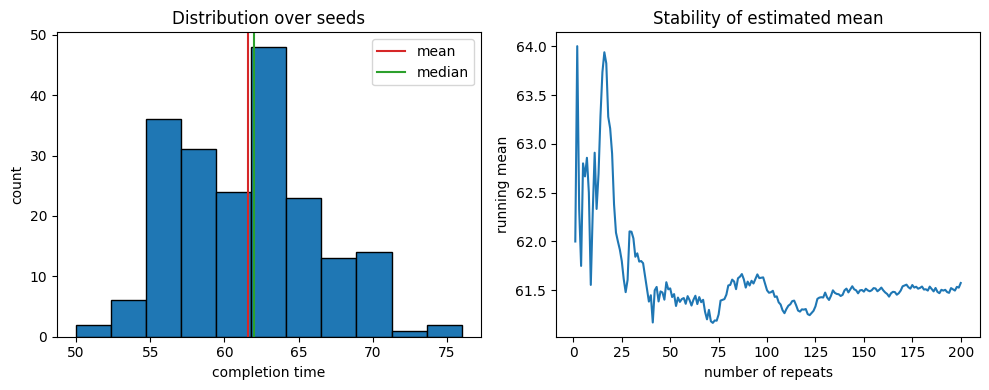

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(times, bins='auto', edgecolor='black')
axes[0].axvline(times.mean(), color='tab:red', label='mean')
axes[0].axvline(np.median(times), color='tab:green', label='median')
axes[0].set(xlabel='completion time', ylabel='count', title='Distribution over seeds')
axes[0].legend()
running_mean = np.cumsum(times) / np.arange(1, n_repeats + 1)
axes[1].plot(np.arange(1, n_repeats + 1), running_mean)
axes[1].set(xlabel='number of repeats', ylabel='running mean', title='Stability of estimated mean')
plt.tight_layout(); plt.show()

## 5. 反復回数と標準誤差

In [6]:
rows = []
for n in [10, 30, 100, 200]:
    sample = times[:n]
    standard_error = sample.std(ddof=1) / np.sqrt(n)
    rows.append([n, sample.mean(), np.median(sample), sample.std(ddof=1), standard_error])
pd.DataFrame(rows, columns=['repeats', 'mean', 'median', 'std', 'standard error'])

,repeats,mean,median,std,standard error
0,10,62.300,62.0,4.398232,1.390843
1,30,62.100,61.5,5.677238,1.036517
2,100,61.500,62.0,5.161043,0.516104
3,200,61.575,62.0,4.729292,0.334411


## 6. 課題

1. seedを固定したまま繰り返す誤った実験を作り、分散がどう見えるか確認する。
2. 反復回数を変え、平均と標準誤差を記録する。
3. 乗降基礎章のCAを複数seedで実行する研究用Notebookを別に作る。まず基準モデルだけの分布を保存する。
4. 固定・横移動・一時降車などの代替ルールは、基準分布を確認した後に1つずつ学生自身で実装する。